# Assignment 1 -> Data Preprocessing and Visualization

### Objective
Perform data preprocessing, normalization, train-test splitting, and data visualization on a sample dataset using TensorFlow/Keras.

**Dataset:** MNIST handwritten digits  
**Framework:** TensorFlow / Keras  
**Environment:** Google Colab / Python 3


## 1. Import Required Libraries

TensorFlow/Keras is used to load the MNIST dataset and build the neural network, while Matplotlib is used for visualization.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the MNIST Dataset

MNIST contains grayscale images of handwritten digits from **0 to 9**. The Keras dataset loader provides a predefined training set and test set, so the train-test split is already available.

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing images shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


## 3. Data Preprocessing and Normalization

Each MNIST image contains pixel values in the range **0–255**. Dividing by 255 converts the values to the range **0–1**, which makes the input scale more suitable for neural-network training.

In [3]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Training pixel range:", train_images.min(), "to", train_images.max())
print("Testing pixel range:", test_images.min(), "to", test_images.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


## 4. Visualize a Sample Image

The following visualization displays one normalized MNIST image along with its corresponding class label.

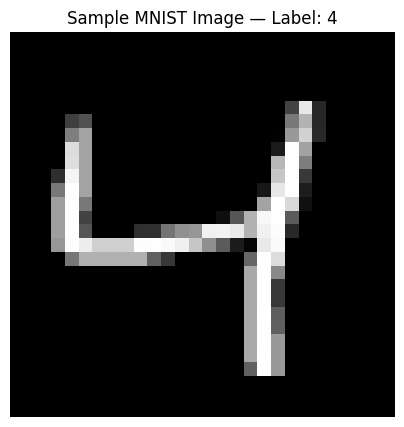

In [4]:
sample_index = 2

plt.figure(figsize=(5, 5))
plt.imshow(train_images[sample_index], cmap="gray")
plt.title(f"Sample MNIST Image — Label: {train_labels[sample_index]}")
plt.axis("off")
plt.show()

## 5. Verify the Train-Test Split

The MNIST dataset supplied by Keras contains **60,000 training images** and **10,000 testing images**. The test set is kept separate from training so that the trained model can be evaluated on unseen data.

In [5]:
print(f"Training samples: {len(train_images)}")
print(f"Testing samples: {len(test_images)}")
print(f"Training split: {len(train_images) / (len(train_images) + len(test_images)):.0%}")
print(f"Testing split: {len(test_images) / (len(train_images) + len(test_images)):.0%}")

Training samples: 60000
Testing samples: 10000
Training split: 86%
Testing split: 14%


## 6. Build a Simple Neural Network

A basic fully connected neural network is used to demonstrate how the preprocessed data can be supplied to a Keras model. `Flatten` converts each 28×28 image into a one-dimensional vector, followed by a hidden dense layer and a 10-class softmax output layer.

In [6]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

The model is trained for three epochs using the normalized training images and their labels.

In [7]:
history = model.fit(
    train_images,
    train_labels,
    epochs=3,
    verbose=1
)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9254 - loss: 0.2625
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9661 - loss: 0.1139
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9764 - loss: 0.0780


## 8. Evaluate on the Test Set

The trained model is evaluated using the separate test set to measure its performance on unseen images.

In [8]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9705 - loss: 0.0955
Test loss: 0.0955
Test accuracy: 97.05%


## 9. Visualize Training Performance

Training accuracy and loss are plotted to observe how the model performs across epochs.

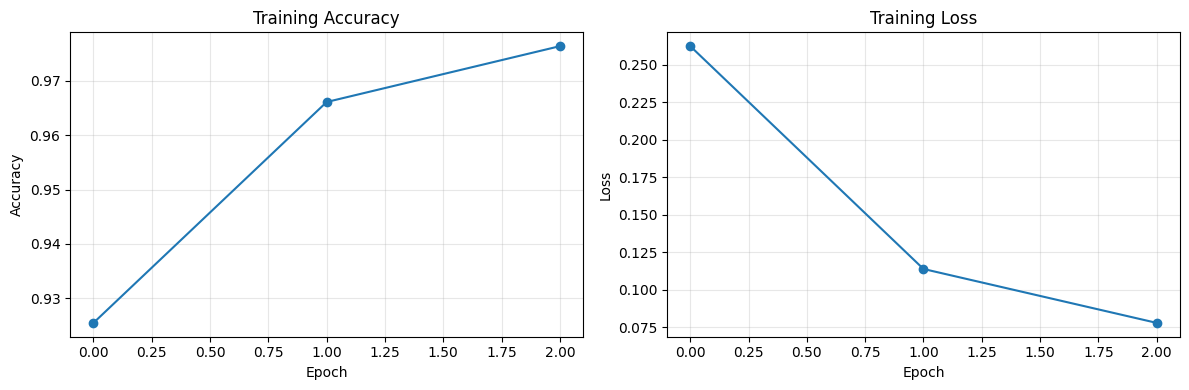

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], marker="o")
axes[0].set_title("Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"], marker="o")
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Save the Trained Model

The trained Keras model is saved in the modern `.keras` format for later reuse.

In [10]:
model.save("mnist_dense_model.keras")
print("Model saved successfully as mnist_dense_model.keras")

Model saved successfully as mnist_dense_model.keras


## Conclusion

- Loaded the MNIST sample dataset using TensorFlow/Keras.
- Verified the predefined training and testing split.
- Normalized image pixel values from 0–255 to 0–1.
- Visualized a sample handwritten digit.
- Built and trained a simple neural network for digit classification.
- Evaluated the model on unseen test data.
- Visualized training performance and saved the trained model.